In [9]:
#Project - Object Detection - Vehicle Damage Detection yolo26

#vehicle_damage_detection → project purpose
#yolo26 → model used

In [10]:
#1.Import the libraries used throughout the notebook

import os
# import → keyword used to load a module into the program
# os → built-in module for interacting with the operating system (file paths, directories, environment variables)

import yaml
# import → keyword used to load a module into the program
# yaml → library for reading/writing YAML files (commonly used for YOLO dataset config files)

from pathlib import Path
# from → keyword to import a specific part of a module
# pathlib → built-in module for object-oriented filesystem paths
# import → keyword used to load a module/class into the program
# Path → class from pathlib used to create and manipulate file/folder paths


from ultralytics import YOLO
# from → keyword to import a specific part of a module
# ultralytics → third-party library containing the YOLO object detection framework
# import → keyword used to load a module/class into the program
# YOLO → class used to load, train, and run YOLO detection models

import matplotlib.pyplot as plt
# import → keyword used to load a module into the program
# matplotlib.pyplot → plotting module used to create graphs and display images
# as → keyword to assign an alias/shortcut name
# plt → alias used to refer to matplotlib.pyplot in the code

from PIL import Image
# from → keyword to import a specific part of a module
# PIL → Python Imaging Library (Pillow), used for image processing
# import → keyword used to load a module/class into the program
# Image → class used to open, edit, and display image files

# Summary: Imports all core tools needed — file/config handling, the YOLO model, and image plotting

In [11]:
#2.# SET DATASET PATH & LOAD CONFIG

DATASET_DIR = Path("Automobile Damage Detection.v4i.yolo26")
# DATASET_DIR → variable name storing the dataset folder path
# = → assignment operator, stores the right-side value into the left-side variable
# Path → class from pathlib used to create a filesystem path object
# "Automobile Damage Detection.v4i.yolo26" → string, the folder name of the dataset

DATA_YAML = DATASET_DIR / "data.yaml"
# DATA_YAML → variable name storing the path to the data.yaml file
# DATASET_DIR → the folder path defined above
# / → path-joining operator (from pathlib), combines folder and filename
# "data.yaml" → string, the name of the YAML config file inside the dataset folder


# READ THE YAML CONFIG FILE

with open(DATA_YAML, "r") as f:
    # with → context manager keyword, ensures the file is properly closed after use
    # open → built-in function that opens a file
    # DATA_YAML → the file path to open
    # "r" → mode argument, means "read mode" (read-only, text)
    # as f → assigns the opened file object to the variable "f"

    data_config = yaml.safe_load(f)
    # data_config → variable storing the parsed YAML content as a Python dictionary
    # = → assignment operator
    # yaml → the yaml library imported earlier
    # safe_load → method that safely parses YAML text into Python objects
    # (f) → the file object being read


# DISPLAY DATASET INFO

print("Number of classes:", data_config["nc"])
# print → built-in function that outputs text to the console
# "Number of classes:" → string label describing the value being printed
# data_config → the dictionary loaded from the YAML file
# ["nc"] → dictionary key access, retrieves the value for "nc" (number of classes)

print("Class names:", data_config["names"])
# print → built-in function that outputs text to the console
# "Class names:" → string label describing the value being printed
# data_config → the dictionary loaded from the YAML file
# ["names"] → dictionary key access, retrieves the value for "names" (list of class labels)

# Summary: Loads the dataset's data.yaml file and prints the number of classes and their names

Number of classes: 14
Class names: ['Front-windscreen-damage', 'Headlight-damage', 'Rear-windscreen-Damage', 'Runningboard-Damage', 'Sidemirror-Damage', 'Taillight-Damage', 'bonnet-dent', 'boot-dent', 'doorouter-dent', 'fender-dent', 'front-bumper-dent', 'quaterpanel-dent', 'rear-bumper-dent', 'roof-dent']


In [4]:
#3.LOAD PRETRAINED MODEL

# Load a pretrained YOLO26 model as the starting point (transfer learning)

model = YOLO("yolo26n.pt")  # 'n' = nano, the smallest and fastest variant
# model → variable name storing the loaded YOLO model object
# = → assignment operator, stores the right-side value into the left-side variable
# YOLO → class imported earlier, used to load/create a YOLO model
# ("yolo26n.pt") → argument passed to YOLO, the filename of the pretrained weights file
# "yolo26n.pt" → string, pretrained weight file for the YOLO26 nano model
# # 'n' = nano, the smallest and fastest variant → comment explaining that "n" denotes the nano-sized model variant

# Summary: Loads a pretrained YOLO26 nano model to use as the starting point for transfer learning

In [5]:
#4.TRAIN THE MODEL

#Train (fine-tune) the model on the automobile damage dataset

results = model.train(
    data=str(DATA_YAML),
    epochs=20,
    imgsz=320,
    batch=8,
    patience=5,
    project="damage_detection",
    name="yolo26_run1"
)

# results → variable name storing the training output/results object
# = → assignment operator, stores the right-side value into the left-side variable
# model → the YOLO model object loaded earlier
# .train → method that starts the training process on the model
# ( → opens the argument list for the train() method
# data → parameter specifying the dataset config file to use
# = → assigns a value to the parameter
# str(DATA_YAML) → converts the DATA_YAML Path object into a plain string
# epochs → parameter specifying how many times the model sees the full dataset
# = → assigns a value to the parameter
# 20 → number of training epochs
# imgsz → parameter specifying the input image size for training
# = → assigns a value to the parameter
# 320 → image size in pixels (320x320, balances speed and accuracy)
# batch → parameter specifying how many images are processed together per step
# = → assigns a value to the parameter
# 8 → batch size value
# patience → parameter specifying early-stopping tolerance (epochs without improvement)
# = → assigns a value to the parameter
# 5 → number of epochs to wait before stopping if no improvement
# project → parameter specifying the parent folder name for saving results
# = → assigns a value to the parameter
# "damage_detection" → string, name of the project folder
# name → parameter specifying the sub-folder name for this specific run
# = → assigns a value to the parameter
# "yolo26_run1" → string, name of this training run
# ) → closes the argument list and the train() method call

# Summary: Trains the YOLO model on the custom dataset using a moderate image size (320x320) for a balance between speed and accuracy

Ultralytics 8.4.129  Python-3.13.9 torch-2.13.0+cpu CPU (Intel Core i3-4130 3.40GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Automobile Damage Detection.v4i.yolo26\data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26_run1-3

In [12]:
#5.LOAD THE TRAINED MODEL (BEST WEIGHTS)

from ultralytics import YOLO
# from → keyword to import a specific part of a module
# ultralytics → third-party library containing the YOLO object detection framework
# import → keyword used to load a module/class into the program
# YOLO → class used to load, train, and run YOLO detection models

model = YOLO(r"E:\Hope AI Course\Deep Learning - Object Detection - Project\runs\detect\damage_detection\yolo26_run1-3\weights\best.pt")
# model → variable name storing the loaded YOLO model object
# = → assignment operator, stores the right-side value into the left-side variable
# YOLO → class imported above, used to load/create a YOLO model
# ( → opens the argument list for the YOLO constructor
# r"..." → raw string (the r prefix stops backslashes from being treated as escape characters)
# E:\Hope AI Course\Deep Learning - Object Detection - Project\runs\detect\damage_detection\yolo26_run1-3\weights\best.pt → file path to the 
# saved best-performing model weights from training
# ) → closes the argument list and the YOLO constructor call

# Summary: Reloads the model using the best-performing trained weights saved from the training run

In [13]:
#6.EVALUATE THE MODEL

#Evaluate the trained model on the validation set

metrics = model.val()
# metrics → variable name storing the evaluation results object
# = → assignment operator, stores the right-side value into the left-side variable
# model → the trained YOLO model object
# .val → method that runs validation/evaluation on the model using the validation dataset
# () → empty argument list, uses default validation settings

print("mAP50-95:", metrics.box.map)
# print → built-in function that outputs text to the console
# "mAP50-95:" → string label describing the value being printed
# metrics → the evaluation results object
# .box → attribute holding bounding-box related evaluation metrics
# .map → attribute holding the mean Average Precision averaged over IoU thresholds 0.5–0.95

print("mAP50:", metrics.box.map50)
# print → built-in function that outputs text to the console
# "mAP50:" → string label describing the value being printed
# metrics → the evaluation results object
# .box → attribute holding bounding-box related evaluation metrics
# .map50 → attribute holding the mean Average Precision at IoU threshold 0.5

# Summary: Runs validation on the trained model and prints its mAP50-95 and mAP50 accuracy scores

Ultralytics 8.4.129  Python-3.13.9 torch-2.13.0+cpu CPU (Intel Core i3-4130 3.40GHz)
YOLO26n summary (fused): 122 layers, 2,377,566 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 287.7228.5 MB/s, size: 76.5 KB)
val: Scanning E:\Hope AI Course\Deep Learning - Object Detection - Project\Automobile Damage Detection.v4i.yolo26\valid\labels.cache... 1037 images, 0 backgrounds, 6 corrupt: 100% ━━━━━━━━━━━━ 1043/1043 190.2Mit/s 0.0s
val: E:\Hope AI Course\Deep Learning - Object Detection - Project\Automobile Damage Detection.v4i.yolo26\valid\images\many-wrecked-car-traffic-accident-crash-restore-service-maintenance-station-garage-indoor-insurance-salvage-vehicle-214824015_jpg.rf.c4225672698c3a041c1a6c3471d98975.jpg: ignoring corrupt image/label: [Errno 2] No such file or directory: 'E:\\Hope AI Course\\Deep Learning - Object Detection - Project\\Automobile Damage Detection.v4i.yolo26\\valid\\images\\many-wrecked-car-traffic-accident-crash-restore-service-m

In [14]:
#7.VIEW PER-CLASS METRICS

print("Precision per class:", metrics.box.p)
# print → built-in function that outputs text to the console
# "Precision per class:" → string label describing the value being printed
# metrics → the evaluation results object from model.val()
# .box → attribute holding bounding-box related evaluation metrics
# .p → attribute holding the precision score for each class

print("Recall per class:", metrics.box.r)
# print → built-in function that outputs text to the console
# "Recall per class:" → string label describing the value being printed
# metrics → the evaluation results object from model.val()
# .box → attribute holding bounding-box related evaluation metrics
# .r → attribute holding the recall score for each class

# Summary: Prints the precision and recall scores broken down by each class

Precision per class: [     0.6148     0.54863     0.84985     0.35153     0.84596     0.77163     0.69343      0.4765     0.69171     0.59351     0.71305     0.74507     0.79114     0.51329]
Recall per class: [       0.58     0.51111     0.73514     0.25532     0.95238     0.63889     0.64583     0.15385     0.68254     0.47945     0.65141     0.59483     0.63576     0.42105]


In [15]:
#8.RUN PREDICTIONS ON TEST IMAGES

#Run predictions on the held-out test images

test_images_dir = DATASET_DIR / "test" / "images"
# test_images_dir → variable name storing the path to the test images folder
# = → assignment operator, stores the right-side value into the left-side variable
# DATASET_DIR → the dataset folder path defined earlier
# / → path-joining operator (from pathlib), combines folder names
# "test" → string, the test subfolder name
# / → path-joining operator, combines with the next folder name
# "images" → string, the images subfolder name inside "test"

predict_results = model.predict(
    source=str(test_images_dir),
    conf=0.4,
    save=True,
    project="damage_detection",
    name="predictions"
)
# predict_results → variable name storing the prediction output/results object
# = → assignment operator, stores the right-side value into the left-side variable
# model → the trained YOLO model object
# .predict → method that runs inference (object detection) on given input images
# ( → opens the argument list for the predict() method
# source → parameter specifying the input images/folder to run predictions on
# = → assigns a value to the parameter
# str(test_images_dir) → converts the test_images_dir Path object into a plain string
# conf → parameter specifying the minimum confidence threshold for detections
# = → assigns a value to the parameter
# 0.4 → confidence threshold value (40%), detections below this are ignored
# save → parameter specifying whether to save the predicted images with drawn boxes
# = → assigns a value to the parameter
# True → boolean, saves the output prediction images
# project → parameter specifying the parent folder name for saving results
# = → assigns a value to the parameter
# "damage_detection" → string, name of the project folder
# name → parameter specifying the sub-folder name for this prediction run
# = → assigns a value to the parameter
# "predictions" → string, name of this prediction run folder
# ) → closes the argument list and the predict() method call

print(f"Ran predictions on {len(predict_results)} test images.")
# print → built-in function that outputs text to the console
# f"..." → f-string, allows embedding variable values directly inside the string
# "Ran predictions on " → literal string text
# {len(predict_results)} → embedded expression, counts the number of items in predict_results
# len → built-in function that returns the length/count of a collection
# (predict_results) → the prediction results object being measured
# " test images." → literal string text

# Summary: Runs the trained model on all test images, saves the annotated outputs, and prints how many images were processed


image 1/698 E:\Hope AI Course\Deep Learning - Object Detection - Project\Automobile Damage Detection.v4i.yolo26\test\images\0020_JPEG_jpg.rf.6e9dae2970b66c9cf28e48a0de6c5b4f.jpg: 320x320 1 Rear-windscreen-Damage, 191.8ms
image 2/698 E:\Hope AI Course\Deep Learning - Object Detection - Project\Automobile Damage Detection.v4i.yolo26\test\images\0030_JPEG_jpg.rf.4deb9ea5a16e3e86dcab01f11184ad50.jpg: 320x320 (no detections), 113.4ms
image 3/698 E:\Hope AI Course\Deep Learning - Object Detection - Project\Automobile Damage Detection.v4i.yolo26\test\images\0045_JPEG_jpg.rf.6d432df55240a7139330d0217f084e85.jpg: 320x320 1 Rear-windscreen-Damage, 99.1ms
image 4/698 E:\Hope AI Course\Deep Learning - Object Detection - Project\Automobile Damage Detection.v4i.yolo26\test\images\0046_JPEG_jpg.rf.29237559bdd864402f7817bde8d46686.jpg: 320x320 1 Rear-windscreen-Damage, 93.3ms
image 5/698 E:\Hope AI Course\Deep Learning - Object Detection - Project\Automobile Damage Detection.v4i.yolo26\test\images\00

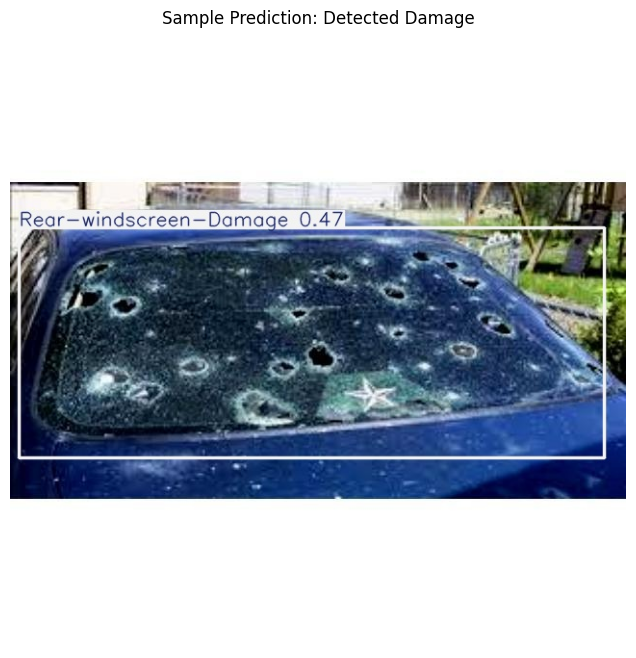

In [22]:
#9.DISPLAY A SAMPLE PREDICTION IMAGE

#Display one predicted (annotated) image inside the notebook

pred_dir = Path(r"E:\Hope AI Course\Deep Learning - Object Detection - Project\runs\detect\damage_detection\predictions")
# pred_dir → variable name storing the path to the predictions folder
# = → assignment operator, stores the right-side value into the left-side variable
# Path → class from pathlib used to create a filesystem path object
# ( → opens the argument list for Path
# r"..." → raw string (the r prefix stops backslashes from being treated as escape characters)
# E:\Hope AI Course\Deep Learning - Object Detection - Project\runs\detect\damage_detection\predictions → file path to the folder where 
# predicted images were saved
# ) → closes the argument list for Path

sample_image = next(pred_dir.glob("*.jpg"))
# sample_image → variable name storing the path to one sample prediction image
# = → assignment operator, stores the right-side value into the left-side variable
# next → built-in function that retrieves the first item from an iterator
# ( → opens the argument list for next()
# pred_dir → the predictions folder path defined above
# .glob → method that searches for files matching a pattern
# ("*.jpg") → argument passed to glob, matches any file ending in ".jpg"
# ) → closes the argument list for next()

img = Image.open(sample_image)
# img → variable name storing the opened image object
# = → assignment operator, stores the right-side value into the left-side variable
# Image → class imported from PIL, used for image handling
# .open → method that opens an image file
# (sample_image) → argument passed to open, the path to the image file to load

plt.figure(figsize=(8, 8))
# plt → matplotlib.pyplot module imported earlier
# .figure → method that creates a new figure/canvas for plotting
# ( → opens the argument list for figure()
# figsize → parameter specifying the width and height of the figure
# = → assigns a value to the parameter
# (8, 8) → tuple, sets figure size to 8x8 inches
# ) → closes the argument list for figure()

plt.imshow(img)
# plt → matplotlib.pyplot module
# .imshow → method that displays an image on the current figure
# (img) → argument passed to imshow, the image object to display

plt.axis("off")
# plt → matplotlib.pyplot module
# .axis → method that controls the axis display settings
# ("off") → argument passed to axis, hides the x/y axis lines and labels

plt.title("Sample Prediction: Detected Damage")
# plt → matplotlib.pyplot module
# .title → method that sets the title text above the plot
# ("Sample Prediction: Detected Damage") → argument passed to title, the string shown as the title

plt.show()
# plt → matplotlib.pyplot module
# .show → method that renders and displays the figure on screen
# () → empty argument list, no additional parameters needed

# Summary: Loads one sample prediction image and displays it with a title, without axis lines

In [21]:
#10.ENABLE INLINE PLOTTING

%matplotlib inline
# % → symbol indicating a Jupyter magic command
# matplotlib → refers to the matplotlib plotting library
# inline → magic argument that tells Jupyter to display plots directly below the code cell (instead of in a separate window)

# Summary: Enables plots (like images and graphs) to display directly inside the Jupyter notebook

In [23]:
#11.DEFINE FUNCTION TO RUN THE MODEL ON ANY SINGLE IMAGE PATH

#A reusable function to run the model on any single image path

def detect_damage(image_path, confidence=0.4):
    """Run the trained YOLO26 model on one image and display the result."""
# def → keyword used to define a new function
# detect_damage → the name given to this function
# ( → opens the parameter list
# image_path → parameter, the path to the image to run detection on
# , → separates parameters
# confidence → parameter, the minimum confidence threshold, with a default value
# =0.4 → default value assigned if no confidence is provided when calling
# ) → closes the parameter list
# : → begins the function body
# """..."""  → docstring, a description explaining what the function does

    result = model.predict(source=image_path, conf=confidence, save=False)[0]
# result → variable storing the prediction output for this single image
# = → assignment operator, stores the right-side value into the left-side variable
# model → the trained YOLO model object
# .predict → method that runs inference (object detection) on the input
# ( → opens the argument list for predict()
# source → parameter specifying the input image
# =image_path → assigns the function's image_path argument as the source
# , → separates arguments
# conf → parameter specifying the confidence threshold
# =confidence → assigns the function's confidence argument
# , → separates arguments
# save → parameter specifying whether to save output images
# =False → boolean, does not save the image to disk
# ) → closes the argument list for predict()
# [0] → indexing, retrieves the first (and only) result since one image was passed

    for box in result.boxes:
# for → keyword starting a loop
# box → loop variable, represents one detected object per iteration
# in → keyword linking the loop variable to the collection being iterated
# result.boxes → attribute holding all detected bounding boxes in this result
# : → begins the loop body

        cls_id = int(box.cls[0])
# cls_id → variable storing the numeric class ID of the detected object
# = → assignment operator
# int → built-in function that converts a value to an integer
# ( → opens the argument list for int()
# box.cls → attribute holding the class ID tensor for this detected box
# [0] → indexing, retrieves the first (only) value from the tensor
# ) → closes the argument list for int()

        cls_name = data_config["names"][cls_id]
# cls_name → variable storing the human-readable class name
# = → assignment operator
# data_config → the dictionary loaded from data.yaml earlier
# ["names"] → dictionary key access, retrieves the list of class names
# [cls_id] → list indexing, retrieves the class name matching this ID

        conf_score = float(box.conf[0])
# conf_score → variable storing the confidence score of this detection
# = → assignment operator
# float → built-in function that converts a value to a decimal number
# ( → opens the argument list for float()
# box.conf → attribute holding the confidence score tensor for this box
# [0] → indexing, retrieves the first (only) value from the tensor
# ) → closes the argument list for float()

        print(f"Detected: {cls_name}  (confidence: {conf_score:.2f})")
# print → built-in function that outputs text to the console
# f"..." → f-string, allows embedding variable values directly inside the string
# "Detected: " → literal string text
# {cls_name} → embedded expression, inserts the detected class name
# "  (confidence: " → literal string text
# {conf_score:.2f} → embedded expression, inserts the confidence score formatted to 2 decimal places
# ")" → literal string text

    annotated = result.plot()
# annotated → variable storing the image with detection boxes drawn on it
# = → assignment operator
# result → the prediction result object
# .plot → method that draws bounding boxes/labels onto the image and returns it as an array

    plt.figure(figsize=(8, 8))
# plt → matplotlib.pyplot module
# .figure → method that creates a new figure/canvas for plotting
# (figsize=(8, 8)) → sets the figure size to 8x8 inches

    plt.imshow(annotated[:, :, ::-1])
# plt → matplotlib.pyplot module
# .imshow → method that displays an image on the current figure
# ( → opens the argument list for imshow()
# annotated → the annotated image array
# [:, :, ::-1] → slicing, reverses the color channel order (BGR to RGB) for correct display
# ) → closes the argument list for imshow()

    plt.axis("off")
# plt → matplotlib.pyplot module
# .axis → method that controls axis display settings
# ("off") → hides the x/y axis lines and labels

    plt.show()
# plt → matplotlib.pyplot module
# .show → method that renders and displays the figure on screen
# () → empty argument list

    return result
# return → keyword that sends a value back to wherever the function was called
# result → the prediction result object being returned

# Summary: Defines a reusable function that runs detection on a single image, prints each detected class with its confidence, 
#and displays the annotated image

In [24]:
#12.EXPORT THE MODEL TO ONNX FORMAT

#Export the trained model to ONNX format for easier deployment

model.export(format="onnx")
# model → the trained YOLO model object
# .export → method that converts and saves the model to a different file format
# ( → opens the argument list for export()
# format → parameter specifying the target export format
# = → assigns a value to the parameter
# "onnx" → string, exports the model in ONNX format (a cross-platform model format)
# ) → closes the argument list for export()

# Summary: Exports the trained YOLO model into ONNX format for use outside Ultralytics/PyTorch

Ultralytics 8.4.129  Python-3.13.9 torch-2.13.0+cpu CPU (Intel Core i3-4130 3.40GHz)
 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino

PyTorch: starting from 'E:\Hope AI Course\Deep Learning - Object Detection - Project\runs\detect\damage_detection\yolo26_run1-3\weights\best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 300, 6) (5.1 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/17.2 MB ? eta -:--:--
    --------------------------------------- 0.3/17.2 MB ? eta -:--:--
   --- ------------------------------------ 1.3/17.2 MB 5.1 MB/s eta 0:00:04
   ----- ---------------------------------- 2.4/17.2 MB 4.8 MB/s eta 0:00:04
   -------- ------------------------------- 3.7/17.2 MB 5.5 MB/s eta 0:00:03
   ------------ --------------------------- 

'E:\\Hope AI Course\\Deep Learning - Object Detection - Project\\runs\\detect\\damage_detection\\yolo26_run1-3\\weights\\best.onnx'

E:\Hope AI Course\Deep Learning - Object Detection - Project\Automobile Damage Detection.v4i.yolo26\test\images\0020_JPEG_jpg.rf.6e9dae2970b66c9cf28e48a0de6c5b4f.jpg

image 1/1 E:\Hope AI Course\Deep Learning - Object Detection - Project\Automobile Damage Detection.v4i.yolo26\test\images\0020_JPEG_jpg.rf.6e9dae2970b66c9cf28e48a0de6c5b4f.jpg: 320x320 1 Rear-windscreen-Damage, 96.9ms
Speed: 2.5ms preprocess, 96.9ms inference, 0.5ms postprocess per image at shape (1, 3, 320, 320)
Detected: Rear-windscreen-Damage  (confidence: 0.47)


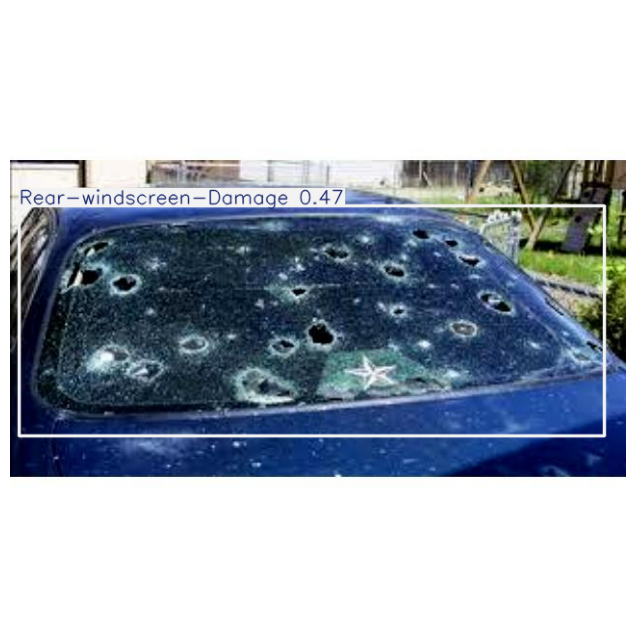

In [28]:
#13.LOAD BEST MODEL AND RUN DETECTION ON A CUSTOM IMAGE

best_model = YOLO(r"E:\Hope AI Course\Deep Learning - Object Detection - Project\runs\detect\damage_detection\yolo26_run1-3\weights\best.pt")
# best_model → variable name storing the loaded YOLO model object
# = → assignment operator, stores the right-side value into the left-side variable
# YOLO → class imported earlier, used to load/create a YOLO model
# ( → opens the argument list for the YOLO constructor
# r"..." → raw string (the r prefix stops backslashes from being treated as escape characters)
# E:\Hope AI Course\...\yolo26_run1-3\weights\best.pt → file path to the best-performing trained weights
# ) → closes the argument list for the YOLO constructor

# Replace this path with any car image you want to test
test_dir = Path(r"E:\Hope AI Course\Deep Learning - Object Detection - Project\Automobile Damage Detection.v4i.yolo26\test\images")
# test_dir → variable name storing the path to the folder containing test images
# = → assignment operator, stores the right-side value into the left-side variable
# Path → class from pathlib used to create a filesystem path object
# ( → opens the argument list for Path
# r"..." → raw string (the r prefix stops backslashes from being treated as escape characters)
# E:\Hope AI Course\...\test\images → file path to the folder holding test images
# ) → closes the argument list for Path

custom_image_path = str(next(test_dir.glob("*.jpg")))
# custom_image_path → variable name storing the path to one chosen test image, as a string
# = → assignment operator, stores the right-side value into the left-side variable
# str → built-in function that converts a value into a string
# ( → opens the argument list for str()
# next → built-in function that retrieves the first item from an iterator
# ( → opens the argument list for next()
# test_dir → the test images folder path defined above
# .glob → method that searches for files matching a pattern
# ("*.jpg") → argument passed to glob, matches any file ending in ".jpg"
# ) → closes the argument list for next()
# ) → closes the argument list for str()

print(custom_image_path)  # confirm it picked a real file
# print → built-in function that outputs text to the console
# (custom_image_path) → the variable being printed, the chosen image path
# # confirm it picked a real file → comment explaining the purpose of this print statement

result = detect_damage(custom_image_path, confidence=0.4)
# result → variable storing the output returned by the detect_damage function
# = → assignment operator, stores the right-side value into the left-side variable
# detect_damage → the custom function defined earlier
# ( → opens the argument list for detect_damage()
# custom_image_path → the image path variable defined above, passed as the image_path argument
# , → separates arguments
# confidence → parameter specifying the detection confidence threshold
# =0.4 → assigns 0.4 (40%) as the confidence threshold
# ) → closes the argument list for detect_damage()

# Summary: Loads the best trained model, automatically picks the first test image from the folder, confirms the path, 
# then runs detection and displays the result